# Verrauschte Prozesszeitreihen: Datenqualität, Spektralanalyse, Tiefpassfilterung, STL und MSTL

In diesem Notebook wird der öffentliche Datensatz **Individual Household Electric Power Consumption** als Beispiel für den Energieverbrauch eines technischen Standorts verwendet. Die Daten stammen zwar aus einem einzelnen Haushalt, werden hier aber als Stellvertreter für einen technischen Versorgungsbereich, einen Chemiepark oder einen industriellen Standort interpretiert.

Im Mittelpunkt stehen reale, verrauschte Zeitreihen. Es geht um Datenqualität, sinnvolle Arbeitsauflösungen, Spektralanalyse, Filterung und Zerlegung in Trend, saisonale Muster und Residuen.

## Lizenz, Nutzung und Quelle

Dieses Notebook ist Work in Progress und kann im Lehrbetrieb angepasst werden.

Datensatz:

- Name: Individual Household Electric Power Consumption
- Quelle: UCI Machine Learning Repository
- DOI: `10.24432/C58K54`
- Datensatzgeber: Georges Hebrail und Alice Berard
- Lizenz laut UCI: Creative Commons Attribution 4.0 International, kurz CC BY 4.0

Zitation nach UCI:

> Hebrail, G. & Berard, A. (2006). Individual Household Electric Power Consumption [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C58K54

Der Datensatz enthält Messwerte elektrischer Größen mit einer Abtastung von einer Minute über fast vier Jahre. Im Notebook wird primär `Global_active_power` verwendet.

## Lerninhalte und Lernziele

<div style="border-left: 4px solid #4F81BD; background:#F7FBFF; padding:10px 12px; margin:8px 0;">
<b>Lernziel</b><br>
Nach diesem Notebook können Sie eine verrauschte technische Zeitreihe im Zeit- und Frequenzbereich untersuchen und markante STrukturen erkennen / isolieren.
</div>

Nach der Bearbeitung können Sie:

- einen Zeitindex prüfen und Datenlücken erkennen,
- fehlende Werte mit einfachen Methoden behandeln,
- hohe Originalauflösung und resampelte Daten gezielt einsetzen,
- Periodogramm und Welch-PSD vergleichen,
- dominante Perioden aus einem Leistungsdichtespektrum ableiten,
- einen Butterworth-Tiefpassfilter begründen und anwenden,
- STL und MSTL für saisonale Zeitreihen nutzen,
- Residuen mit ACF und Spektralanalyse bewerten.

PSD steht für Power Spectral Density, deutsch: Leistungsdichtespektrum oder spektrale Leistungsdichte. STL steht für Seasonal-Trend decomposition using LOESS. MSTL steht für Multiple Seasonal-Trend decomposition using LOESS.

## Datensatz und Bezug

Die Zielgröße `Global_active_power` beschreibt die mittlere Wirkleistung pro Minute. Im technischen Sinn kann diese Größe als Gesamtlast eines Standorts gelesen werden.

Typische Fragestellungen sind:

- Gibt es kurze Lastspitzen oder schnelle Fluktuationen?
- Welche Tages-, Wochen- oder Betriebszyklen sind sichtbar?
- Welche Signalanteile werden durch Glättung oder Tiefpassfilterung entfernt?
- Bleibt nach STL oder MSTL noch systematische Struktur im Residuum?

Phasen mit niedrigerem Verbrauch sind dabei keine Fehler sondern können andere Nutzungs- oder Betriebsphasen darstellen, zum Beispiel reduzierte Last, Wartung, Abwesenheit oder saisonal veränderten Energiebedarf. In der Prozessindustrie können ähnliche Effekte durch Außentemperatur, Kühlwasserbedingungen, Schichtbetrieb, Wartung oder geänderte Produktionslast entstehen.

## Konfiguration

Start- und Enddatum können frei gesetzt oder deaktiviert werden. Für eine schnelle erste Ausführung kann ein Teilfenster gewählt werden; für eine vollständige Analyse kann der gesamte Datensatz verwendet werden.

In [84]:
from pathlib import Path

# -----------------------------
# Datenquelle und Zielgröße
# -----------------------------
DATA_PATH = Path("./data/household_power_consumption.txt")  # lokale Textdatei des UCI-Datensatzes
AUTO_DOWNLOAD_DATA = True  # True: Datensatz herunterladen, falls DATA_PATH noch nicht existiert

VALUE_COL = "Global_active_power"  # Zielspalte für die meisten Analysen
VALUE_LABEL = "Global active power [kW]"  # Achsenbeschriftung mit Einheit
VALUE_UNIT = "kW"  # Einheit für Differenzsignale und Tabellen

# -----------------------------
# Zeitraum
# -----------------------------
USE_DATE_RANGE = True         # True: Zeitraum über START_DATE und END_DATE begrenzen
START_DATE = 2007-01-01               # Beispiel: "2007-01-01"; None: automatisch ab Datenbeginn
END_DATE = 2007-03-31                 # Beispiel: "2007-03-31"; None: automatisch bis Datenende

# -----------------------------
# Zeitindex und Interpolation
# -----------------------------
EXPECTED_FREQ = "1min"          # erwartete Originalauflösung: eine Messung pro Minute
MAX_GAP_FOR_INTERPOLATION = 12   # nur Lücken bis zu dieser Länge werden gezielt interpoliert
SPLINE_CONTEXT_POINTS = 4        # gültige Stützpunkte links/rechts für lokale kubische Splines
FILL_REMAINING_FOR_ANALYSIS = True  # True: verbleibende NaN-Werte für PSD/Filterung vollständig auffüllen

# -----------------------------
# Glättung und Peaks
# -----------------------------
ROLLING_WINDOW = "60min"        # Fenster für den gleitenden Mittelwert in Originalauflösung
PEAK_PROMINENCE_FACTOR = 3.0     # Faktor auf robuste Streuung; höhere Werte finden weniger Peaks
MAX_PEAK_MARKERS = 100           # begrenzt Peak-Marker, damit lange Plots lesbar bleiben

# -----------------------------
# Spektralanalyse
# -----------------------------
WELCH_NPERSEG = 7 * 24 * 60      # 7 Tage * 24 Stunden/Tag * 60 Minuten/Stunde bei Minutendaten
WELCH_OVERLAP_RATIO = 0.5        # 0.5 bedeutet: benachbarte Welch-Segmente überlappen zu 50 %
PSD_MIN_PERIOD = "30min"         # kleinste betrachtete Periodendauer im Spektrum
PSD_MAX_PERIOD = "14D"           # größte betrachtete Periodendauer im Spektrum
N_DOMINANT_PERIODS = 10          # Anzahl der ausgegebenen lokalen PSD-Maxima

# -----------------------------
# Butterworth-Tiefpass
# -----------------------------
FILTER_ORDER = 4                 # Filterordnung; höhere Ordnung bedeutet steilerer Übergang
CUTOFF_PERIOD = "1h"             # Startwert: schnelle Schwankungen unterhalb von ca. 1 h dämpfen

# -----------------------------
# Resampling, STL und MSTL
# -----------------------------
USE_RESAMPLING_FOR_DECOMPOSITION = True
RESAMPLE_FREQ = "1h"             # Arbeitsauflösung für Tages-, Wochen- und Betriebszyklen
RESAMPLE_AGG = "mean"            # "mean": mittlere Leistung; "median": robuster gegen einzelne Peaks
RESAMPLED_ROLLING_WINDOW = "24h" # Glättung der resampelten Zeitreihe über einen Tag

STL_PERIOD = 24                  # 24 Samples bei stündlichen Daten: Tagesmuster
MSTL_PERIODS = (24, 168)  # 6 h, 8 h, 12 h, 24h - 1 Tag,168 h - 1 Woche bei stündlichen Daten
STL_ROBUST = True                # robuste STL-Variante reduziert den Einfluss einzelner Ausreißer

# -----------------------------
# Plotfenster
# -----------------------------
OVERVIEW_WINDOW = "14D"          # größerer Ausschnitt für Übersichtsplots
ZOOM_WINDOW = "2D"               # Detailausschnitt für Zoomplots
ZOOM_START = None                # None: automatisch aus dem Datenfenster wählen

# Farben für Periodenmarkierungen
DAY_COLOR = "green"
WEEK_COLOR = "red"
HALF_DAY_COLOR = "purple"
EIGHT_HOUR_COLOR = "tab:orange"
SIX_HOUR_COLOR = "tab:blue"


## Imports

Die folgenden Bibliotheken werden für Datenverarbeitung, Signalverarbeitung, Visualisierung und Zeitreihenzerlegung verwendet.

In [8]:
import warnings
import zipfile
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.interpolate import CubicSpline
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.seasonal import STL

try:
    from statsmodels.tsa.seasonal import MSTL
except ImportError:
    MSTL = None

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True


## Hilfsfunktionen

Einige Hilfsfunktionen bündeln wiederkehrende Schritte, zum Beispiel Lückenblöcke, Spektren, Periodenmarkierungen und kompakte Plots. Sehr kurze Einzelschritte bleiben direkt in den jeweiligen Codezellen, damit der Ablauf im Notebook nachvollziehbar bleibt.


In [10]:
def robust_sigma(series):
    """Robuste Streuung über Median Absolute Deviation schätzen."""
    values = series.dropna().to_numpy()
    if len(values) == 0:
        return np.nan
    med = np.median(values)
    mad = np.median(np.abs(values - med))
    sigma = 1.4826 * mad
    if sigma == 0 or np.isnan(sigma):
        sigma = np.nanstd(values)
    return sigma


def get_nan_blocks(series):
    """Zusammenhängende NaN-Blöcke in einer Zeitreihe bestimmen."""
    is_missing = series.isna()
    if not is_missing.any():
        return pd.DataFrame(columns=["start", "end", "length"])
    block_id = (is_missing != is_missing.shift(fill_value=False)).cumsum()
    rows = []
    for _, block in is_missing.groupby(block_id):
        if bool(block.iloc[0]):
            rows.append({"start": block.index[0], "end": block.index[-1], "length": len(block)})
    return pd.DataFrame(rows)


def recursive_interpolate(series, max_gap=None):
    """Lücken schrittweise zwischen linkem und rechtem Randwert auffüllen."""
    result = series.astype(float).copy()
    values = result.to_numpy(copy=True)
    n = len(values)
    i = 0

    while i < n:
        if not np.isnan(values[i]):
            i += 1
            continue

        start = i
        while i < n and np.isnan(values[i]):
            i += 1
        end = i - 1
        length = end - start + 1

        left_pos = start - 1
        right_pos = end + 1
        can_fill = (
            left_pos >= 0
            and right_pos < n
            and not np.isnan(values[left_pos])
            and not np.isnan(values[right_pos])
            and (max_gap is None or length <= max_gap)
        )

        if can_fill:
            last_value = values[left_pos]
            right_value = values[right_pos]
            for pos in range(start, end + 1):
                remaining_missing = right_pos - pos
                last_value = last_value + (right_value - last_value) / (remaining_missing + 1)
                values[pos] = last_value

    return pd.Series(values, index=series.index, name=series.name)


def cubic_gap_interpolate(series, gap_table, max_gap=None, context_points=4):
    """Kleine Lücken lokal mit einem kubischen Spline über benachbarte Stützpunkte füllen."""
    result = series.astype(float).copy()
    original_values = series.astype(float).to_numpy()
    valid_positions = np.flatnonzero(~np.isnan(original_values))

    if len(valid_positions) < 4 or gap_table.empty:
        return result

    x_all = (series.index - series.index[0]).total_seconds().to_numpy(dtype=float)

    for _, row in gap_table.iterrows():
        length = int(row["length"])
        if max_gap is not None and length > max_gap:
            continue

        start_pos = series.index.get_loc(row["start"])
        end_pos = series.index.get_loc(row["end"])
        insert_at = np.searchsorted(valid_positions, start_pos)

        left_positions = valid_positions[max(0, insert_at - context_points):insert_at]
        right_positions = valid_positions[insert_at:min(len(valid_positions), insert_at + context_points)]
        support_positions = np.r_[left_positions, right_positions]

        # Ein kubischer Spline braucht mindestens vier Stützpunkte.
        if len(support_positions) < 4:
            continue

        x_support = x_all[support_positions]
        y_support = original_values[support_positions]
        gap_positions = np.arange(start_pos, end_pos + 1)

        try:
            spline = CubicSpline(x_support, y_support, bc_type="natural")
            result.iloc[gap_positions] = spline(x_all[gap_positions])
        except Exception:
            # Wenn der lokale Spline nicht berechnet werden kann, bleibt die Lücke unverändert.
            continue

    return result


def select_window(index, duration, start=None):
    """Ein Zeitfenster aus einem DatetimeIndex auswählen."""
    duration_td = pd.to_timedelta(duration)
    if start is None:
        start_ts = index.min() + (index.max() - index.min()) * 0.35
    else:
        start_ts = pd.Timestamp(start)
    end_ts = min(start_ts + duration_td, index.max())
    return start_ts, end_ts


def sampling_rate_cycles_per_day(index):
    """Abtastfrequenz in Zyklen pro Tag berechnen."""
    dt_seconds = index.to_series().diff().dropna().dt.total_seconds().median()
    return 86400.0 / dt_seconds


def compute_spectrum(series, method="welch", nperseg=None):
    """Periodogramm oder Welch-PSD mit Frequenzachse in Zyklen pro Tag berechnen."""
    y = series.dropna().to_numpy(dtype=float)
    y = y - np.nanmean(y)
    fs_cpd = sampling_rate_cycles_per_day(series.dropna().index)

    if method == "periodogram":
        freqs, psd = signal.periodogram(y, fs=fs_cpd, detrend="constant", scaling="density")
    elif method == "welch":
        if nperseg is None:
            nperseg = min(WELCH_NPERSEG, len(y))
        nperseg = max(8, min(int(nperseg), len(y)))
        noverlap = int(nperseg * WELCH_OVERLAP_RATIO)
        freqs, psd = signal.welch(
            y,
            fs=fs_cpd,
            nperseg=nperseg,
            noverlap=noverlap,
            detrend="constant",
            scaling="density",
        )
    else:
        raise ValueError("method must be 'periodogram' or 'welch'")

    valid = freqs > 0
    return freqs[valid], psd[valid]


def period_label_from_days(days):
    """Periodendauer in gut lesbare Einheiten umwandeln."""
    if days < 1 / 24:
        return f"{days * 24 * 60:.1f} min"
    if days < 1:
        return f"{days * 24:.1f} h"
    if days < 14:
        return f"{days:.2f} d"
    return f"{days / 7:.2f} Wochen"


def frequency_limits_from_periods(min_period, max_period):
    """Kleinste/größte Periodendauer in Frequenzgrenzen umrechnen."""
    min_days = pd.to_timedelta(min_period) / pd.Timedelta(days=1)
    max_days = pd.to_timedelta(max_period) / pd.Timedelta(days=1)
    return 1 / max_days, 1 / min_days


def add_period_markers(ax, include_week=True, include_subdaily_extra=False):
    """Relevante Perioden auf einer Frequenzachse in Zyklen pro Tag markieren."""
    markers = [
        (1.0, "1 Tag", DAY_COLOR),
        (2.0, "12 h", HALF_DAY_COLOR),
    ]
    if include_subdaily_extra:
        markers.extend(
            [
                (3.0, "8 h", EIGHT_HOUR_COLOR),
                (4.0, "6 h", SIX_HOUR_COLOR),
            ]
        )
    if include_week:
        markers.append((1 / 7, "1 Woche", WEEK_COLOR))

    for freq, label, color in markers:
        ax.axvline(freq, color=color, linestyle="--", linewidth=1.2, alpha=0.85, label=label)


def plot_overview_and_zoom(series_dict, ylabel: str, title: str, overview_window=OVERVIEW_WINDOW, zoom_window=ZOOM_WINDOW):
    """Dieselben Signale in Übersicht und Zoom darstellen."""
    base = next(iter(series_dict.values())).dropna()
    overview_start, overview_end = select_window(base.index, overview_window, ZOOM_START)
    zoom_start, zoom_end = select_window(base.index, zoom_window, overview_start)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
    windows = [(overview_start, overview_end, "Ausschnitt"), (zoom_start, zoom_end, "Zoom")]
    for ax, (start, end, subtitle) in zip(axes, windows):
        for label, ser in series_dict.items():
            window = ser.loc[start:end]
            ax.plot(window.index, window, label=label, linewidth=1.2)
        ax.set_title(subtitle)
        ax.set_xlabel("Zeit")
        ax.set_ylabel(ylabel)
        ax.legend(loc="best")
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


## Daten laden

Wenn die Datendatei lokal vorhanden ist, wird sie direkt genutzt. Wenn sie fehlt und `AUTO_DOWNLOAD_DATA = True` gesetzt ist, wird der UCI-Datensatz heruntergeladen und entpackt.

In [12]:
if not DATA_PATH.exists():
    if AUTO_DOWNLOAD_DATA:
        DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
        zip_path = DATA_PATH.with_suffix(".zip")
        urls = [
            "https://archive.ics.uci.edu/static/public/235/individual+household+electric+power+consumption.zip",
            "https://archive.ics.uci.edu/ml/machine-learning-databases/00235/household_power_consumption.zip",
        ]

        last_error = None
        for url in urls:
            try:
                print(f"Download: {url}")
                urllib.request.urlretrieve(url, zip_path)
                with zipfile.ZipFile(zip_path, "r") as zf:
                    zf.extract("household_power_consumption.txt", path=DATA_PATH.parent)

                extracted_path = DATA_PATH.parent / "household_power_consumption.txt"
                if extracted_path != DATA_PATH and extracted_path.exists():
                    extracted_path.replace(DATA_PATH)

                print(f"Datei gespeichert unter: {DATA_PATH}")
                break
            except Exception as exc:
                last_error = exc
                print(f"Download über diese URL nicht erfolgreich: {exc}")

        if not DATA_PATH.exists():
            raise FileNotFoundError(
                "Die Datendatei wurde nicht gefunden und der automatische Download war nicht erfolgreich. "
                f"Bitte laden Sie die Datei manuell herunter und speichern Sie sie unter: {DATA_PATH}. "
                f"Letzter Fehler: {last_error}"
            )
    else:
        raise FileNotFoundError(f"Datendatei nicht gefunden: {DATA_PATH}")

raw = pd.read_csv(
    DATA_PATH,
    sep=";",
    na_values=["?", ""],
    low_memory=False,
)

# Datum und Uhrzeit zu einem Zeitstempel zusammenführen
timestamp = pd.to_datetime(
    raw["Date"].astype(str) + " " + raw["Time"].astype(str),
    format="%d/%m/%Y %H:%M:%S",
    errors="coerce",
)

raw = raw.drop(columns=["Date", "Time"])
for col in raw.columns:
    raw[col] = pd.to_numeric(raw[col], errors="coerce")

raw.index = timestamp
raw.index.name = "timestamp"
raw = raw[~raw.index.isna()].sort_index()

if USE_DATE_RANGE:
    raw = raw.loc[START_DATE:END_DATE].copy()

raw.head()


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
timestamp,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


## Zeitindex und Datenqualität prüfen

Eine regelmäßige Zeitachse ohne fehlende Werte ist wichtig, weil Spektralanalyse, Filterung, STL und MSTL auf einer geordneten und regelmäßig abgetasteten Zeitreihe arbeiten. Fehlende Werte können Frequenzanteile verfälschen, Filteroperationen stören oder Zerlegungen abbrechen lassen.

In [14]:
duplicate_timestamps = raw.index.duplicated().sum()
# Bei Duplikaten wird der erste Eintrag behalten. In diesen Daten sollten Duplikate nicht auftreten.
data = raw.loc[~raw.index.duplicated(keep="first")].copy()

regular_index = pd.date_range(data.index.min(), data.index.max(), freq=EXPECTED_FREQ)
regular_index.name = "timestamp"
data_regular = data.reindex(regular_index)

target_raw = data_regular[VALUE_COL].copy()
missing_timestamp_count = len(regular_index.difference(data.index))
missing_value_count = int(target_raw.isna().sum())
gap_blocks = get_nan_blocks(target_raw)

quality_table = pd.DataFrame(
    {
        "Kennwert": [
            "Zeilen nach Zeitraumsauswahl",
            "Start",
            "Ende",
            "Doppelte Zeitstempel",
            "Erwartete Zeitpunkte",
            "Fehlende Zeitpunkte im Index",
            f"Fehlende Werte in {VALUE_COL}",
            "Anzahl Lückenblöcke",
            "Maximale Lückenlänge [Samples]",
        ],
        "Wert": [
            f"{len(data):,}",
            str(data.index.min()),
            str(data.index.max()),
            duplicate_timestamps,
            f"{len(regular_index):,}",
            missing_timestamp_count,
            missing_value_count,
            len(gap_blocks),
            0 if gap_blocks.empty else int(gap_blocks["length"].max()),
        ],
    }
)
quality_table

,Kennwert,Wert
0,Zeilen nach Zeitraumsauswahl,"2,075,259"
1,Start,2006-12-16 17:24:00
2,Ende,2010-11-26 21:02:00
3,Doppelte Zeitstempel,0
4,Erwartete Zeitpunkte,"2,075,259"
5,Fehlende Zeitpunkte im Index,0
6,Fehlende Werte in Global_active_power,25979
7,Anzahl Lückenblöcke,71
8,Maximale Lückenlänge [Samples],7226


In [15]:
total_expected_samples = len(data_regular)

missing_by_column = (
    data_regular.isna()
    .sum()
    .rename("missing_values")
    .to_frame()
    .sort_values("missing_values", ascending=False)
)

missing_by_column["valid_values"] = total_expected_samples - missing_by_column["missing_values"]
missing_by_column["total_expected_samples"] = total_expected_samples
missing_by_column["missing_percent_of_expected_index"] = (
    100 * missing_by_column["missing_values"] / total_expected_samples
)

missing_by_column


,missing_values,valid_values,total_expected_samples,missing_percent_of_expected_index
Global_active_power,25979,2049280,2075259,1.251844
Global_reactive_power,25979,2049280,2075259,1.251844
Voltage,25979,2049280,2075259,1.251844
Global_intensity,25979,2049280,2075259,1.251844
Sub_metering_1,25979,2049280,2075259,1.251844
Sub_metering_2,25979,2049280,2075259,1.251844
Sub_metering_3,25979,2049280,2075259,1.251844


## Fehlende Werte und Interpolation

In technischen Zeitreihen ersetzen interpolierte Werte keine Messinformation. Sie können aber kleine Lücken schließen, damit Spektralanalyse, Filterung, STL und MSTL technisch ausführbar bleiben.

In diesem Notebook werden zwei Methoden verglichen.

**Methode 1: lineare bzw. rekursive Interpolation**

Eine Lücke hat einen bekannten linken Randwert und einen bekannten rechten Randwert. Die fehlenden Werte werden schrittweise zwischen diesen beiden Randwerten aufgefüllt. Für kleine Lücken entsteht dadurch ein einfacher linearer Übergang.

**Methode 2: lokale kubische Spline-Interpolation**

Für Prozesszeitreihen kann eine glattere Interpolation sinnvoll sein, wenn spätere Analysen kontinuierliche Verläufe oder Gradienten betrachten. Ein kubischer Spline nutzt mehrere benachbarte Stützpunkte und erzeugt einen glatteren Übergang als eine reine lineare Verbindung. Das ist zum Beispiel bei Systemidentifikation oder dynamischer Modellierung nützlich.

Die Methode wird hier nur für kleine Lücken verwendet. Größere Lücken sollten fachlich geprüft werden, weil dort der interpolierte Verlauf stark von Annahmen abhängt.


In [17]:
linear_interpolated_limited = recursive_interpolate(target_raw, max_gap=MAX_GAP_FOR_INTERPOLATION)
cubic_interpolated_limited = cubic_gap_interpolate(
    target_raw,
    gap_blocks,
    max_gap=MAX_GAP_FOR_INTERPOLATION,
    context_points=SPLINE_CONTEXT_POINTS,
)

analysis_series = cubic_interpolated_limited.copy()

if FILL_REMAINING_FOR_ANALYSIS and analysis_series.isna().any():
    remaining_before = int(analysis_series.isna().sum())
    # Für die folgenden Signalverarbeitungsverfahren wird eine vollständige Zeitreihe benötigt.
    # Große verbleibende Lücken werden deshalb einfach zeitbasiert gefüllt und später kritisch bewertet.
    analysis_series = analysis_series.interpolate(method="time", limit_direction="both")
    print(f"Für die Analyse wurden zusätzlich {remaining_before:,} verbleibende NaN-Werte zeitbasiert gefüllt.")

print(f"NaN-Werte nach begrenzter linearer/rekursiver Interpolation: {linear_interpolated_limited.isna().sum():,}")
print(f"NaN-Werte nach begrenzter kubischer Spline-Interpolation: {cubic_interpolated_limited.isna().sum():,}")
print(f"NaN-Werte in der Analysezeitreihe: {analysis_series.isna().sum():,}")


Für die Analyse wurden zusätzlich 25,897 verbleibende NaN-Werte zeitbasiert gefüllt.
NaN-Werte nach begrenzter linearer/rekursiver Interpolation: 25,897
NaN-Werte nach begrenzter kubischer Spline-Interpolation: 25,897
NaN-Werte in der Analysezeitreihe: 0


### Grafischer Vergleich der Interpolationsmethoden

Die folgenden Ausschnitte zeigen echte kleine Lücken, wenn im gewählten Zeitraum passende Lücken vorhanden sind. Falls keine geeignete Lücke gefunden wird, wird ein kurzer Demonstrationsausschnitt erzeugt. Die Originaldaten werden dabei nicht überschrieben.

Der Zoom ist bewusst eng gewählt: In der Lücke fehlen die blauen Rohdatenpunkte. Die beiden Interpolationsmethoden zeigen, welche Werte dort ergänzt würden.


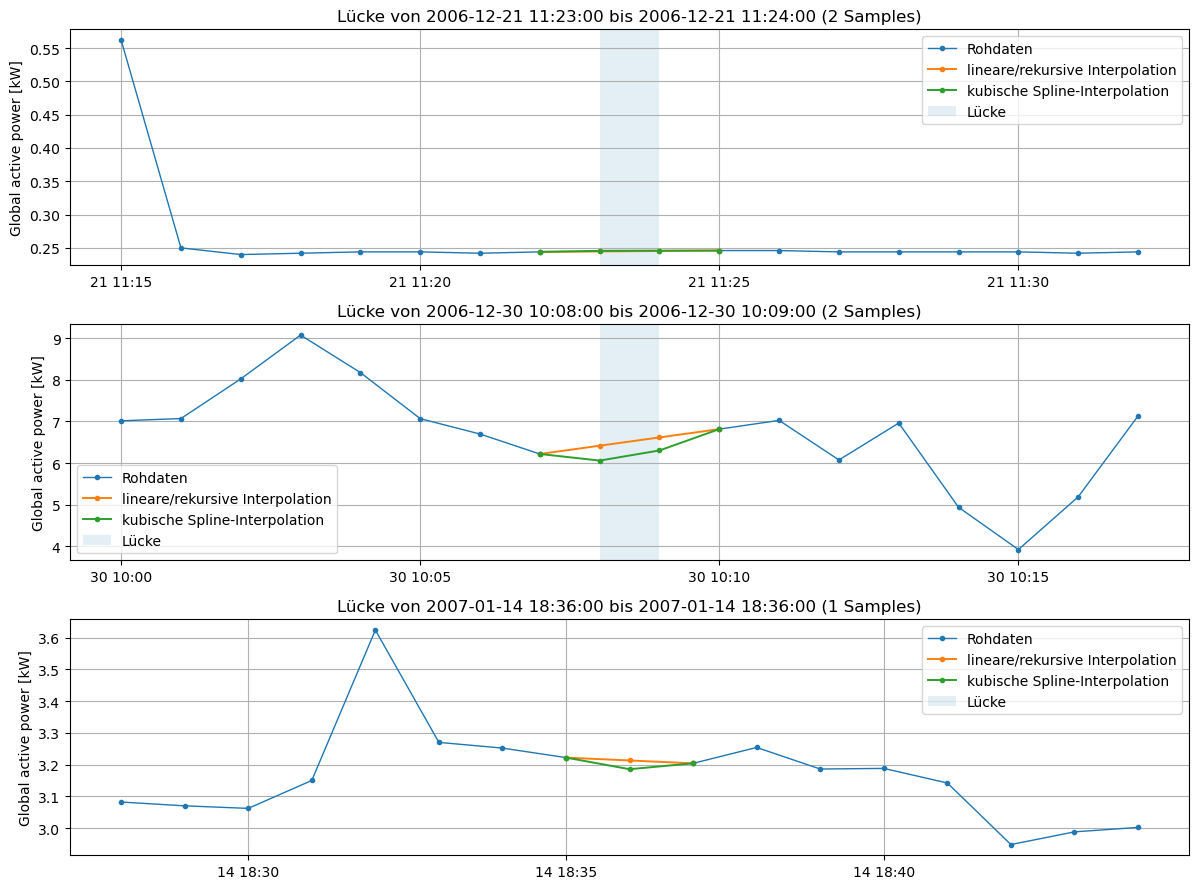

In [19]:
GAP_DEMO_COUNT = 3
GAP_DEMO_MAX_LENGTH = MAX_GAP_FOR_INTERPOLATION
GAP_PLOT_PADDING_POINTS = 8

small_real_gaps = gap_blocks.query("length <= @GAP_DEMO_MAX_LENGTH").head(GAP_DEMO_COUNT)
use_artificial_demo = small_real_gaps.empty

if use_artificial_demo:
    print("Im gewählten Zeitraum wurden keine passenden kurzen echten Lücken gefunden. Es werden Demonstrationslücken erzeugt.")
    demo_series = analysis_series.copy()
    valid_values = demo_series.dropna()
    positions = np.linspace(int(len(valid_values) * 0.25), int(len(valid_values) * 0.75), GAP_DEMO_COUNT, dtype=int)
    lengths = np.linspace(2, min(GAP_DEMO_MAX_LENGTH, 8), GAP_DEMO_COUNT, dtype=int)
    for pos, length in zip(positions, lengths):
        start_label = valid_values.index[pos]
        loc = demo_series.index.get_loc(start_label)
        demo_series.iloc[loc:loc + length] = np.nan
    demo_gaps = get_nan_blocks(demo_series).head(GAP_DEMO_COUNT)
else:
    demo_series = target_raw.copy()
    demo_gaps = small_real_gaps.copy()

linear_demo = recursive_interpolate(demo_series, max_gap=GAP_DEMO_MAX_LENGTH)
cubic_demo = cubic_gap_interpolate(
    demo_series,
    demo_gaps,
    max_gap=GAP_DEMO_MAX_LENGTH,
    context_points=SPLINE_CONTEXT_POINTS,
)

if demo_gaps.empty:
    print("Keine Lücken für die grafische Darstellung verfügbar.")
else:
    dt = pd.to_timedelta(EXPECTED_FREQ)
    fig, axes = plt.subplots(len(demo_gaps), 1, figsize=(12, 3.0 * len(demo_gaps)), sharex=False)
    if len(demo_gaps) == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, demo_gaps.iterrows()):
        start = row["start"] - GAP_PLOT_PADDING_POINTS * dt
        end = row["end"] + GAP_PLOT_PADDING_POINTS * dt
        gap_start_with_boundary = row["start"] - dt
        gap_end_with_boundary = row["end"] + dt

        ax.plot(
            demo_series.loc[start:end],
            marker="o",
            markersize=3,
            linewidth=1.0,
            label="Rohdaten",
        )
        ax.plot(
            linear_demo.loc[gap_start_with_boundary:gap_end_with_boundary],
            marker="o",
            markersize=3,
            linewidth=1.4,
            label="lineare/rekursive Interpolation",
        )
        ax.plot(
            cubic_demo.loc[gap_start_with_boundary:gap_end_with_boundary],
            marker="o",
            markersize=3,
            linewidth=1.4,
            label="kubische Spline-Interpolation",
        )
        ax.axvspan(row["start"], row["end"], alpha=0.12, label="Lücke")
        ax.set_ylabel(VALUE_LABEL)
        ax.set_title(f"Lücke von {row['start']} bis {row['end']} ({int(row['length'])} Samples)")
        ax.legend(loc="best")

    fig.tight_layout()
    plt.show()


## Analyse in hoher Originalauflösung

Die hohe Originalauflösung wird für schnelle Signalanteile genutzt: Rauschen, Peaks, schnelle Fluktuationen, Periodogramm, Welch-PSD und Tiefpassfilter.

Der gleitende Mittelwert reduziert schnelle Schwankungen und kann einzelne Peaks deutlich abschwächen oder vollständig überdecken. Deshalb werden Peaks und schnelle Signalanteile zuerst in möglichst hoher Auflösung untersucht. Für Tages- und Wochenmuster wird später zusätzlich resampelt.


In [21]:
rolling_mean = analysis_series.rolling(ROLLING_WINDOW, center=True, min_periods=1).mean()

sigma = robust_sigma(analysis_series)
prominence_threshold = PEAK_PROMINENCE_FACTOR * sigma
peaks, peak_props = signal.find_peaks(
    analysis_series.to_numpy(),
    prominence=prominence_threshold,
)

peak_index = analysis_series.index[peaks]
peak_values = analysis_series.iloc[peaks]

print(f"Robuste Streuung: {sigma:.3f} {VALUE_UNIT}")
print(f"Prominence-Schwelle: {prominence_threshold:.3f} {VALUE_UNIT}")
print(f"Gefundene Peaks: {len(peaks):,}")

Robuste Streuung: 0.602 kW
Prominence-Schwelle: 1.806 kW
Gefundene Peaks: 13,355


## Gleitender Mittelwert und Peak Detection

Der gleitende Mittelwert reduziert lokale Schwankungen. Die Peak Detection markiert auffällige Lastspitzen. Beides wird hier gemeinsam betrachtet, weil Peaks und Glättung direkt zusammenhängen.

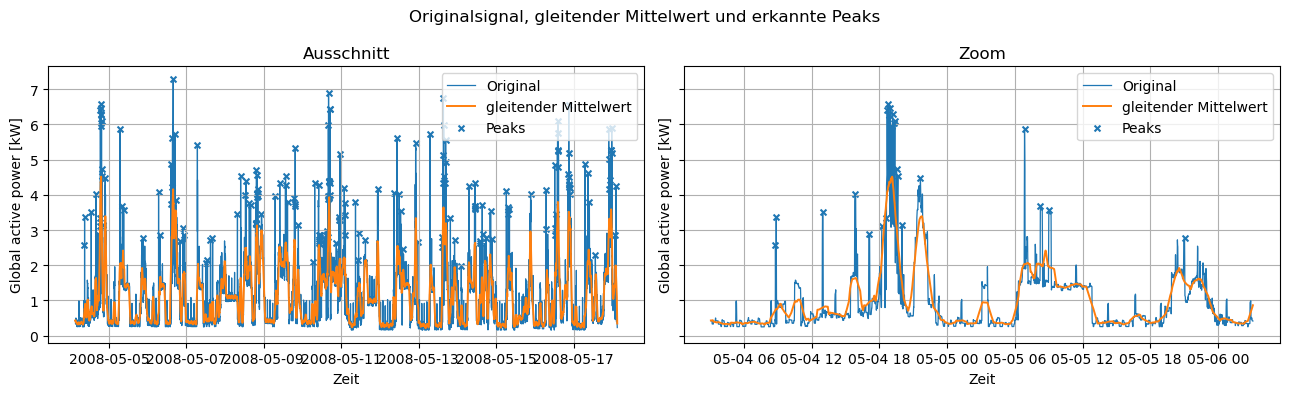

In [23]:
base = analysis_series.dropna()
overview_start, overview_end = select_window(base.index, OVERVIEW_WINDOW, ZOOM_START)
zoom_start, zoom_end = select_window(base.index, ZOOM_WINDOW, overview_start)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, start, end, title in [
    (axes[0], overview_start, overview_end, "Ausschnitt"),
    (axes[1], zoom_start, zoom_end, "Zoom"),
]:
    ax.plot(analysis_series.loc[start:end], label="Original", linewidth=0.9)
    ax.plot(rolling_mean.loc[start:end], label="gleitender Mittelwert", linewidth=1.4)
    peak_mask = (peak_index >= start) & (peak_index <= end)
    peak_idx_window = peak_index[peak_mask][:MAX_PEAK_MARKERS]
    ax.scatter(peak_idx_window, analysis_series.loc[peak_idx_window], s=18, marker="x", label="Peaks")
    ax.set_title(title)
    ax.set_xlabel("Zeit")
    ax.set_ylabel(VALUE_LABEL)
    ax.legend(loc="best")
fig.suptitle("Originalsignal, gleitender Mittelwert und erkannte Peaks")
fig.tight_layout()
plt.show()

## Frequenzgrundlagen

Die Abtastfrequenz $f_s$ beschreibt, wie viele Messwerte pro Zeiteinheit vorliegen. Die Nyquist-Frequenz ist die höchste Frequenz, die bei idealer Abtastung noch eindeutig darstellbar ist:

$$
f_\mathrm{Nyquist} = \frac{f_s}{2}
$$

Frequenz und Periodendauer hängen zusammen über:

$$
T = \frac{1}{f}
$$

Spektralanalyse benötigt eine regelmäßige Abtastung. Starke Trends oder große Mittelwerte können die Interpretation erschweren, weil sie sehr niederfrequente Signalanteile dominieren. Deshalb wird für die PSD-Schätzung der Mittelwert entfernt.

Bei der Welch-PSD wird die Zeitreihe in Segmente aufgeteilt. `nperseg` ist die Segmentlänge. `noverlap` ist die Überlappung benachbarter Segmente. Größere Segmente verbessern die Frequenzauflösung, liefern aber weniger Mittelung. Höhere Überlappung glättet die Schätzung, erhöht aber den Rechenaufwand.

In [25]:
fs_cpd = sampling_rate_cycles_per_day(analysis_series.dropna().index)
nyquist_cpd = fs_cpd / 2
sample_interval = analysis_series.index.to_series().diff().dropna().median()

freq_info = pd.DataFrame(
    {
        "Kennwert": ["Abtastintervall", "Abtastfrequenz [Zyklen/Tag]", "Nyquist-Frequenz [Zyklen/Tag]"],
        "Wert": [str(sample_interval), fs_cpd, nyquist_cpd],
    }
)
freq_info

,Kennwert,Wert
0,Abtastintervall,0 days 00:01:00
1,Abtastfrequenz [Zyklen/Tag],1440.0
2,Nyquist-Frequenz [Zyklen/Tag],720.0


## Periodogramm und Welch-PSD

Das Periodogramm zeigt eine direkte PSD-Schätzung der gesamten Zeitreihe. Die Welch-PSD mittelt PSD-Schätzungen über überlappende Segmente und ist bei verrauschten Daten meist stabiler. Beide Darstellungen werden auf denselben Frequenzbereich begrenzt, damit die relevanten niederfrequenten Muster sichtbar bleiben.

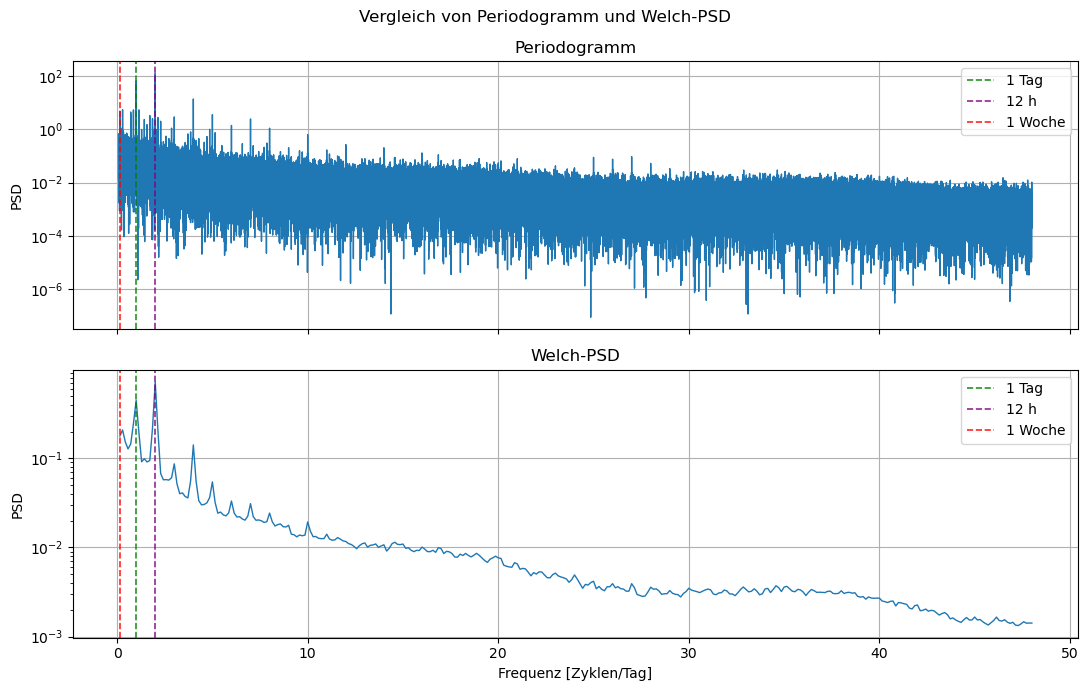

In [27]:
f_periodogram, p_periodogram = compute_spectrum(analysis_series, method="periodogram")
f_welch, p_welch = compute_spectrum(analysis_series, method="welch")
f_min, f_max = frequency_limits_from_periods(PSD_MIN_PERIOD, PSD_MAX_PERIOD)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for ax, freqs, psd, title in [
    (axes[0], f_periodogram, p_periodogram, "Periodogramm"),
    (axes[1], f_welch, p_welch, "Welch-PSD"),
]:
    mask = (freqs >= f_min) & (freqs <= f_max)
    ax.semilogy(freqs[mask], psd[mask], linewidth=1.0)
    add_period_markers(ax, include_week=True)
    ax.set_ylabel("PSD")
    ax.set_title(title)
    ax.legend(loc="best")
axes[-1].set_xlabel("Frequenz [Zyklen/Tag]")
fig.suptitle("Vergleich von Periodogramm und Welch-PSD")
fig.tight_layout()
plt.show()

## Dominante Perioden

Die Tabelle filtert den Frequenzbereich auf Perioden, die für Betriebs-, Tages- oder Wochenmuster relevant sind. Sehr schnelle Schwankungen und extrem langsame Trends werden hier nicht priorisiert.

Die Einträge sind nach dem PSD-Wert sortiert. Ein hoher PSD-Wert bedeutet, dass diese Frequenz im betrachteten Bereich besonders stark zum Signal beiträgt. Typische Kandidaten sind zum Beispiel 12 Stunden, 1 Tag, mehrere Tage oder eine Woche. Die Tabelle liefert aber nur Kandidaten: Ob ein Peak fachlich sinnvoll ist, wird mit Prozesswissen, Zeitplot und später mit der Residualdiagnose beurteilt.


In [29]:
mask = (f_welch >= f_min) & (f_welch <= f_max)
f_sel = f_welch[mask]
p_sel = p_welch[mask]

peak_indices, _ = signal.find_peaks(p_sel)
if len(peak_indices) == 0:
    peak_indices = np.arange(len(p_sel))

top_local = peak_indices[np.argsort(p_sel[peak_indices])[-N_DOMINANT_PERIODS:]][::-1]
dominant_periods = pd.DataFrame(
    {
        "rank_by_psd": np.arange(1, len(top_local) + 1),
        "frequency_cycles_per_day": f_sel[top_local],
        "period_days": 1 / f_sel[top_local],
        "period_readable": [period_label_from_days(1 / f) for f in f_sel[top_local]],
        "psd": p_sel[top_local],
    }
).reset_index(drop=True)

dominant_periods


,rank_by_psd,frequency_cycles_per_day,period_days,period_readable,psd
0,1,2.000000,0.500000,12.0 h,0.723845
1,2,1.000000,1.000000,1.00 d,0.448603
2,3,0.285714,3.500000,3.50 d,0.208463
3,4,4.000000,0.250000,6.0 h,0.141708
4,5,1.428571,0.700000,16.8 h,0.099072
5,6,3.000000,0.333333,8.0 h,0.086830
6,7,2.571429,0.388889,9.3 h,0.057785
7,8,5.000000,0.200000,4.8 h,0.054479
8,9,3.428571,0.291667,7.0 h,0.040985
9,10,6.000000,0.166667,4.0 h,0.033235


## Butterworth-Tiefpassfilter

Ein Butterworth-Tiefpassfilter ist ein glatter digitaler Filter. Er lässt niedrige Frequenzen weitgehend passieren und dämpft höhere Frequenzen. In diesem Notebook wird er verwendet, um schnelle Schwankungen zu reduzieren, während langsamere Muster erhalten bleiben.

Der Cutoff wird über eine Grenzperiode festgelegt. Eine Grenzperiode von etwa einer Stunde ist ein verständlicher Startwert bei Minutendaten. Die Wahl sollte aber aus Fragestellung, Prozesswissen und Spektralanalyse begründet werden.

<div style="border-left: 4px solid #4F81BD; background:#F7FBFF; padding:10px 12px; margin:8px 0;">
<b>Hinweis</b><br>
Beachten Sie, dass ein Tiefpassfilter die Daten verändert! Sie entfernen Frquenzen und verändern damit die Informationen, die im Datensatz enthalten sind. So ist bspw. durchaus ein Mittelwert über eine Zeitspanne nach Filterung verändert.
</div>

Im Code wird `output="sos"` verwendet. SOS steht für Second-Order Sections. Dabei wird der Filter als Kette von Abschnitten zweiter Ordnung dargestellt. `sosfiltfilt` filtert vorwärts und rückwärts. Dadurch entsteht in der Offline-Analyse kein sichtbarer Phasenversatz. Für echte Online-Echtzeitanwendungen ist diese Vorwärts-Rückwärts-Filterung nicht geeignet, weil sie zukünftige Werte verwendet.


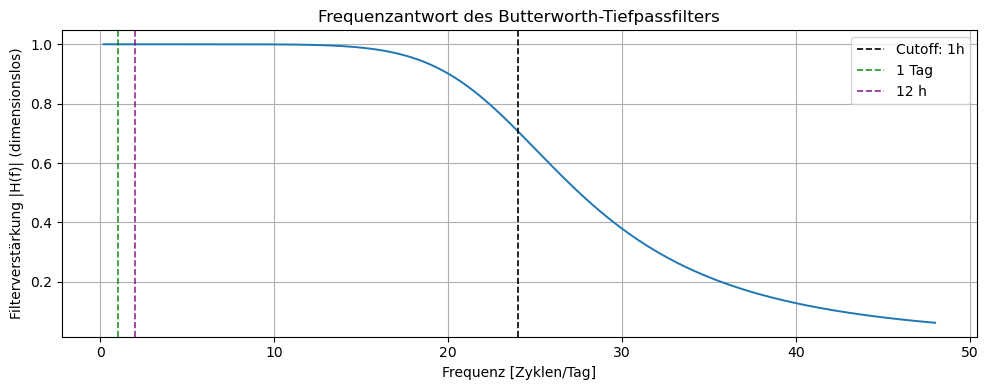

In [31]:
cutoff_days = pd.to_timedelta(CUTOFF_PERIOD) / pd.Timedelta(days=1)
cutoff_cpd = 1 / cutoff_days

# Digitaler Butterworth-Tiefpass in stabiler SOS-Darstellung
sos = signal.butter(
    N=FILTER_ORDER,
    Wn=cutoff_cpd,
    btype="lowpass",
    fs=fs_cpd,
    output="sos",
)

lowpass_values = signal.sosfiltfilt(sos, analysis_series.to_numpy(dtype=float))
lowpass_series = pd.Series(lowpass_values, index=analysis_series.index, name="Butterworth-Tiefpass")

try:
    # Neuere SciPy-Versionen empfehlen freqz_sos.
    w, h = signal.freqz_sos(sos, worN=4096, fs=fs_cpd)
except AttributeError:
    # Fallback für ältere SciPy-Versionen.
    w, h = signal.sosfreqz(sos, worN=4096, fs=fs_cpd)

response_mask = (w >= f_min) & (w <= min(f_max, cutoff_cpd * 12))

plt.figure(figsize=(10, 4))
plt.plot(w[response_mask], np.abs(h[response_mask]), linewidth=1.4)
plt.axvline(cutoff_cpd, color="black", linestyle="--", linewidth=1.2, label=f"Cutoff: {CUTOFF_PERIOD}")
add_period_markers(plt.gca(), include_week=False)
plt.xlabel("Frequenz [Zyklen/Tag]")
plt.ylabel("Filterverstärkung |H(f)| (dimensionslos)")
plt.title("Frequenzantwort des Butterworth-Tiefpassfilters")
plt.legend(loc="best")
plt.tight_layout()
plt.show()


## Vergleich: Original, gleitender Mittelwert und Butterworth-Tiefpass


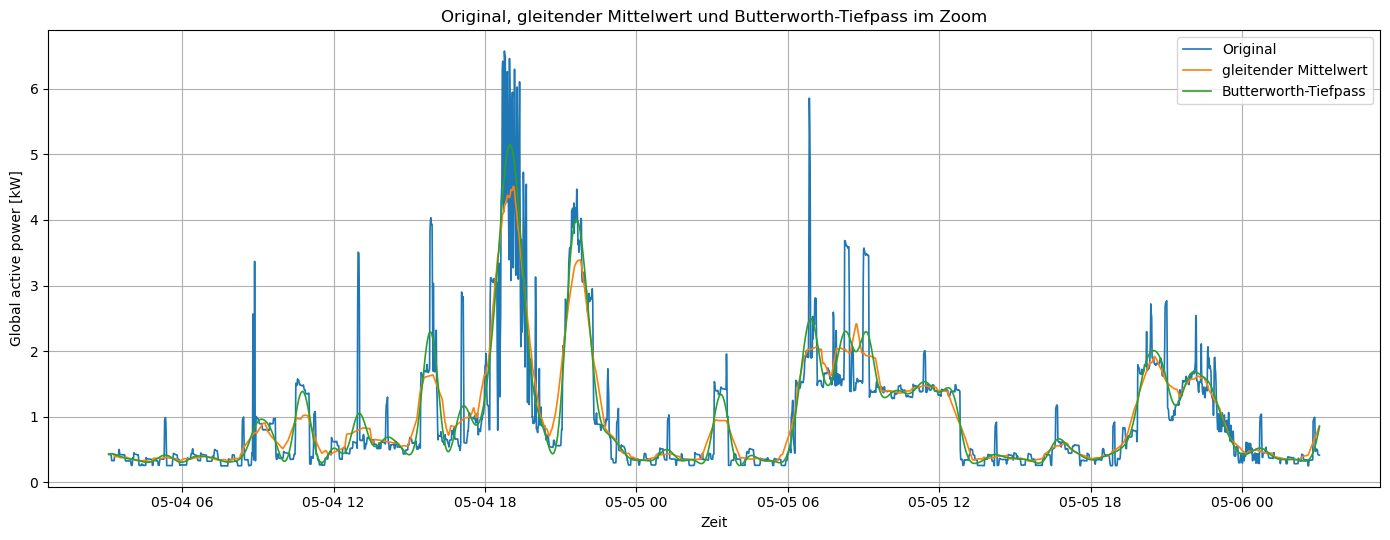

In [33]:
base = analysis_series.dropna()
zoom_start, zoom_end = select_window(base.index, ZOOM_WINDOW, ZOOM_START)

plt.figure(figsize=(14, 5.5))
for label, ser in {
    "Original": analysis_series,
    "gleitender Mittelwert": rolling_mean,
    "Butterworth-Tiefpass": lowpass_series,
}.items():
    window = ser.loc[zoom_start:zoom_end]
    plt.plot(window.index, window, label=label, linewidth=1.2)

plt.xlabel("Zeit")
plt.ylabel(VALUE_LABEL)
plt.title("Original, gleitender Mittelwert und Butterworth-Tiefpass im Zoom")
plt.legend(loc="best")
plt.tight_layout()
plt.show()


## Differenzsignal: Original minus Tiefpass

Das Differenzsignal zeigt den entfernten Anteil. Es ist eine absolute Differenz in derselben Einheit wie das Originalsignal.

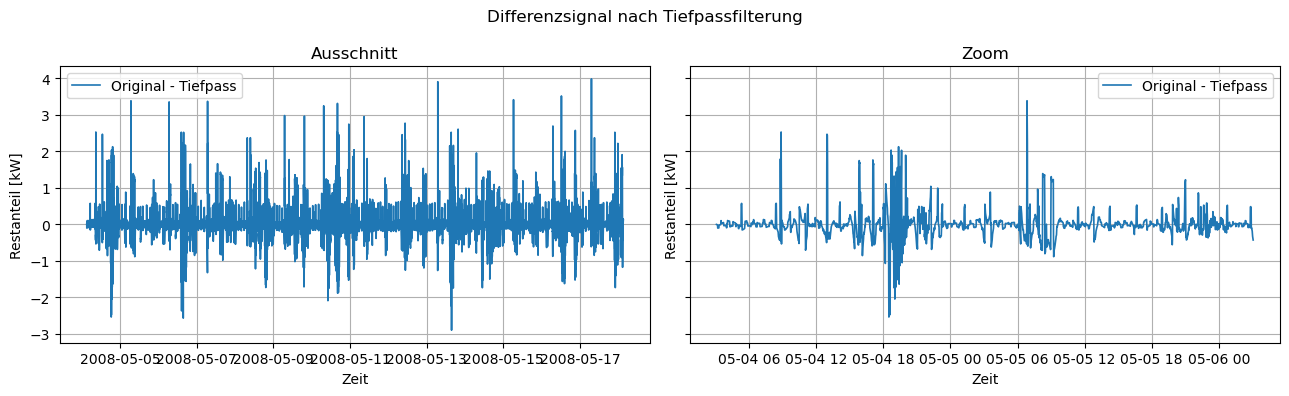

,Kennwert,Restanteil [kW]
0,Mittelwert,0.000001
1,Standardabweichung,0.401154
2,mittlere absolute Abweichung,0.222020


In [35]:
residual_fast = analysis_series - lowpass_series
residual_fast.name = "Restanteil"

plot_overview_and_zoom(
    {"Original - Tiefpass": residual_fast},
    ylabel=f"Restanteil [{VALUE_UNIT}]",
    title="Differenzsignal nach Tiefpassfilterung",
)

pd.DataFrame(
    {
        "Kennwert": ["Mittelwert", "Standardabweichung", "mittlere absolute Abweichung"],
        f"Restanteil [{VALUE_UNIT}]": [
            residual_fast.mean(),
            residual_fast.std(),
            residual_fast.abs().mean(),
        ],
    }
)

## Resampling für langsamere Muster

Für Tages-, Wochen- oder langsamere Betriebs- und Saisonmuster ist die hohe Originalauflösung oft nicht erforderlich. Resampling reduziert die Zeitauflösung und damit auch die Datenmenge. Dabei gehen schnelle Schwankungen innerhalb des Resampling-Intervalls, kurze Peaks und hochfrequente Dynamik verloren.

Der gleitende Mittelwert und der Butterworth-Tiefpass glätten das Signal, behalten aber die ursprüngliche Anzahl an Zeitpunkten. Resampling bildet dagegen neue Zeitintervalle, zum Beispiel Stundenwerte aus Minutendaten. Deshalb eignet es sich gut für STL und MSTL, wenn langsame Muster im Vordergrund stehen.

Bei einer Leistungsgröße in kW ist der Mittelwert pro Intervall meist gut interpretierbar: Er beschreibt die mittlere Leistung im jeweiligen Zeitfenster. Der Median ist robuster gegen einzelne Peaks, verändert aber die fachliche Interpretation stärker. Für echtes Downsampling ist außerdem wichtig, hochfrequente Anteile nicht unkritisch in eine niedrigere Auflösung zu übertragen. In diesem Notebook bleibt die Originalauflösung deshalb für Peaks, Rauschen und Filterung erhalten; die resampelte Reihe wird gezielt für langsamere Muster verwendet.


In [37]:
if RESAMPLE_AGG == "mean":
    resampled_series = analysis_series.resample(RESAMPLE_FREQ).mean()
elif RESAMPLE_AGG == "median":
    resampled_series = analysis_series.resample(RESAMPLE_FREQ).median()
else:
    raise ValueError("RESAMPLE_AGG must be 'mean' or 'median'")

resampled_series = resampled_series.interpolate(method="time", limit_direction="both")
resampled_rolling = resampled_series.rolling(RESAMPLED_ROLLING_WINDOW, center=True, min_periods=1).mean()

data_reduction_percent = 100 * (1 - len(resampled_series) / len(analysis_series))

print(f"Originale Länge: {len(analysis_series):,} Samples")
print(f"Resampelte Länge: {len(resampled_series):,} Samples")
print(f"Datenreduktion: {data_reduction_percent:.1f} %")
print(f"Resampling-Frequenz: {RESAMPLE_FREQ}")
print(f"Aggregation: {RESAMPLE_AGG}")


Originale Länge: 2,075,259 Samples
Resampelte Länge: 34,589 Samples
Datenreduktion: 98.3 %
Resampling-Frequenz: 1h
Aggregation: mean


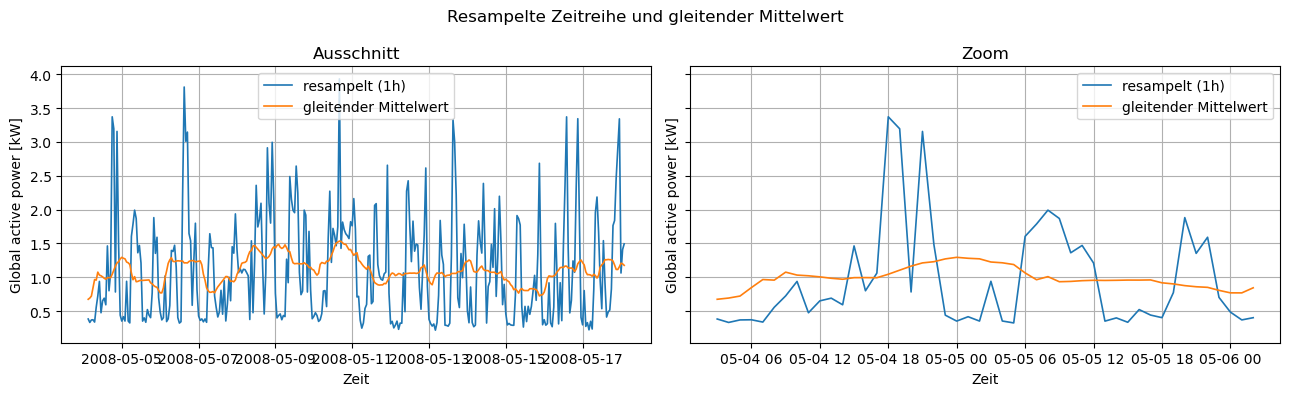

In [38]:
plot_overview_and_zoom(
    {
        f"resampelt ({RESAMPLE_FREQ})": resampled_series,
        "gleitender Mittelwert": resampled_rolling,
    },
    ylabel=VALUE_LABEL,
    title="Resampelte Zeitreihe und gleitender Mittelwert",
)

## Spektralanalyse der resampelten Daten

Die Spektralanalyse der resampelten Daten dient als Übergang zur Periodenwahl für STL und MSTL. Tages- und Wochenmuster sind in niedrigerer Arbeitsauflösung oft klarer sichtbar.

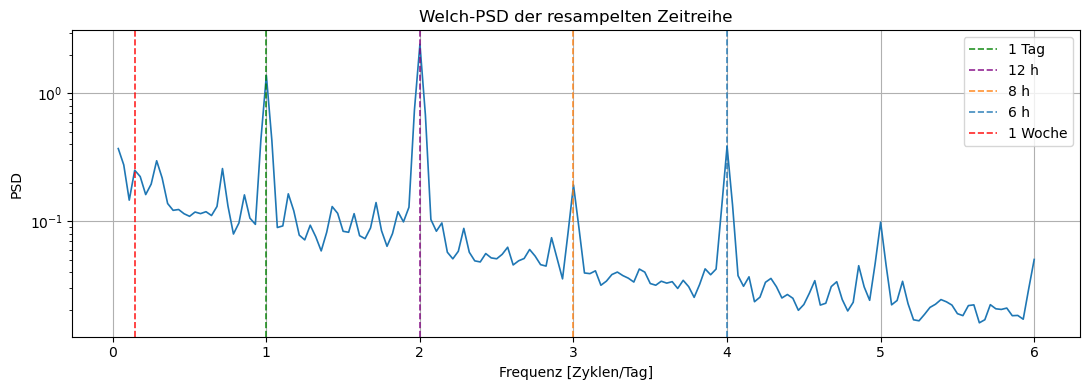

In [40]:
f_resampled, p_resampled = compute_spectrum(resampled_series, method="welch", nperseg=min(24 * 28, len(resampled_series)))
resampled_f_min, resampled_f_max = frequency_limits_from_periods("4h", "60D")

plt.figure(figsize=(11, 4))
mask = (f_resampled >= resampled_f_min) & (f_resampled <= resampled_f_max)
plt.semilogy(f_resampled[mask], p_resampled[mask], linewidth=1.2)
add_period_markers(plt.gca(), include_week=True, include_subdaily_extra=True)
plt.xlabel("Frequenz [Zyklen/Tag]")
plt.ylabel("PSD")
plt.title("Welch-PSD der resampelten Zeitreihe")
plt.legend(loc="best")
plt.tight_layout()
plt.show()


## Periodenwahl für STL und MSTL

Die Perioden für STL und MSTL werden aus Fachwissen, bekannten Betriebs- oder Nutzungsmustern und der Welch-PSD abgeleitet. Peaks im Spektrum liefern Kandidaten, aber nicht jede Topfrequenz muss fachlich sinnvoll sein. Anschließend wird geprüft, ob im Residuum noch systematische Struktur verbleibt.

Die konkreten Perioden müssen zur gewählten Arbeitsauflösung passen. Bei stündlichen Daten entspricht `24` einem Tagesmuster und `168` einem Wochenmuster. Kürzere Kandidaten wie `6`, `8` oder `12` können zusätzliche Muster innerhalb eines Tages abbilden.


In [42]:
decomp_series = resampled_series if USE_RESAMPLING_FOR_DECOMPOSITION else analysis_series

decomp_info = pd.DataFrame(
    {
        "Einstellung": ["Arbeitsauflösung", "STL_PERIOD", "MSTL_PERIODS", "Samples"],
        "Wert": [RESAMPLE_FREQ if USE_RESAMPLING_FOR_DECOMPOSITION else EXPECTED_FREQ, STL_PERIOD, MSTL_PERIODS, len(decomp_series)],
    }
)
decomp_info

,Einstellung,Wert
0,Arbeitsauflösung,1h
1,STL_PERIOD,24
2,MSTL_PERIODS,"(12, 24, 84)"
3,Samples,34589


## STL-Zerlegung

STL steht für Seasonal-Trend decomposition using LOESS. Die Methode zerlegt eine Zeitreihe in Trend, saisonale Komponente und Residuum. Hier wird eine Hauptperiode verwendet, die aus der vorherigen Analyse begründet wurde.

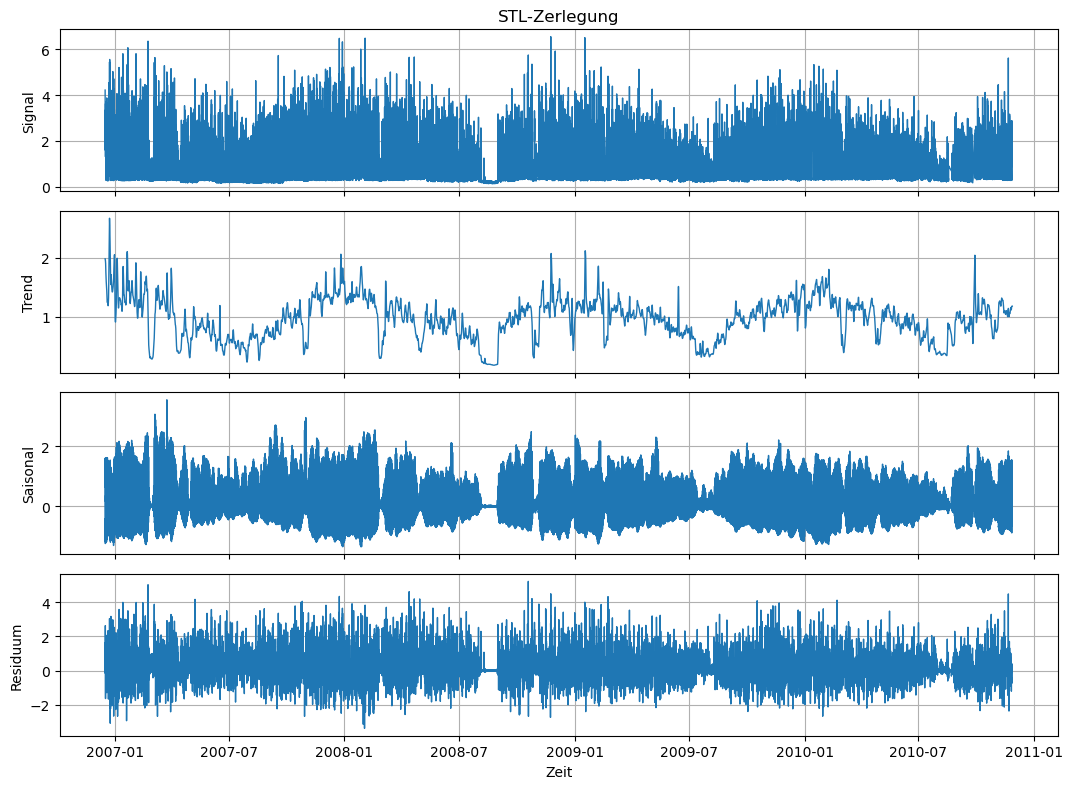

In [44]:
if len(decomp_series) < 2 * STL_PERIOD:
    raise ValueError(
        f"Für STL sind mindestens zwei vollständige Perioden sinnvoll. Vorhanden: {len(decomp_series)}, benötigt: {2 * STL_PERIOD}."
    )

stl_result = STL(decomp_series, period=STL_PERIOD, robust=STL_ROBUST).fit()
stl_components = pd.DataFrame(
    {
        "Signal": decomp_series,
        "Trend": stl_result.trend,
        "Saisonal": stl_result.seasonal,
        "Residuum": stl_result.resid,
    }
)

fig, axes = plt.subplots(4, 1, figsize=(11, 8), sharex=True)
for ax, col in zip(axes, stl_components.columns):
    ax.plot(stl_components[col], linewidth=1.0)
    ax.set_ylabel(col)
axes[0].set_title("STL-Zerlegung")
axes[-1].set_xlabel("Zeit")
fig.tight_layout()
plt.show()

## Bewertung des STL-Residuums

Ein gutes Residuum ist nicht nur klein. Es sollte möglichst wenig systematische Struktur enthalten. Deshalb werden Autokorrelation und Spektrum vor und nach der Zerlegung verglichen.

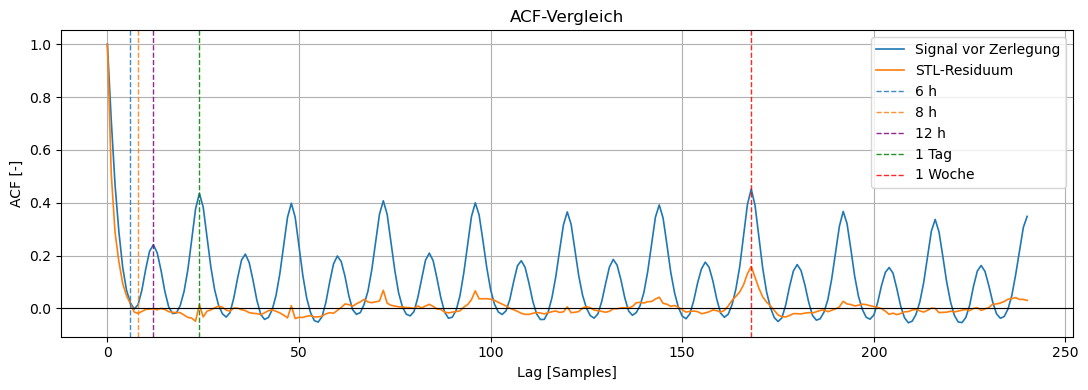

In [46]:
def plot_acf_comparison(series_a, series_b, label_a, label_b, nlags=240):
    """Zwei ACF-Kurven mit Periodenmarkierungen vergleichen."""
    nlags = min(nlags, len(series_a.dropna()) - 2, len(series_b.dropna()) - 2)
    acf_a = acf(series_a.dropna(), nlags=nlags, fft=True)
    acf_b = acf(series_b.dropna(), nlags=nlags, fft=True)
    lags = np.arange(nlags + 1)

    sample_interval = series_a.dropna().index.to_series().diff().dropna().median()
    marker_specs = [
        (pd.Timedelta(hours=6), "6 h", SIX_HOUR_COLOR),
        (pd.Timedelta(hours=8), "8 h", EIGHT_HOUR_COLOR),
        (pd.Timedelta(hours=12), "12 h", HALF_DAY_COLOR),
        (pd.Timedelta(days=1), "1 Tag", DAY_COLOR),
        (pd.Timedelta(days=7), "1 Woche", WEEK_COLOR),
    ]

    plt.figure(figsize=(11, 4))
    plt.plot(lags, acf_a, label=label_a, linewidth=1.2)
    plt.plot(lags, acf_b, label=label_b, linewidth=1.2)
    plt.axhline(0, color="black", linewidth=0.8)

    for period, label, color in marker_specs:
        lag = int(round(period / sample_interval))
        if 0 < lag <= nlags:
            plt.axvline(lag, color=color, linestyle="--", linewidth=1.0, alpha=0.85, label=label)

    plt.xlabel("Lag [Samples]")
    plt.ylabel("ACF [-]")
    plt.title("ACF-Vergleich")
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

plot_acf_comparison(decomp_series, stl_result.resid, "Signal vor Zerlegung", "STL-Residuum", nlags=240)


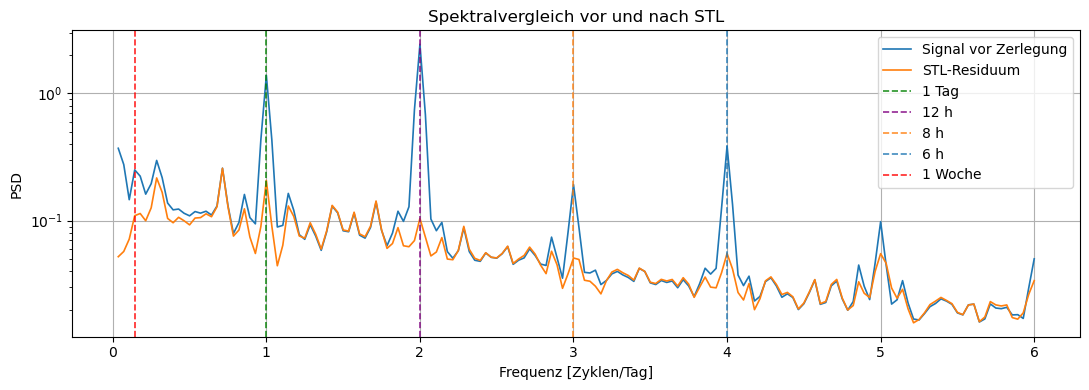

In [47]:
f_signal, p_signal = compute_spectrum(decomp_series, method="welch", nperseg=min(24 * 28, len(decomp_series)))
f_stl_resid, p_stl_resid = compute_spectrum(stl_result.resid, method="welch", nperseg=min(24 * 28, len(stl_result.resid)))

plt.figure(figsize=(11, 4))
mask_signal = (f_signal >= resampled_f_min) & (f_signal <= resampled_f_max)
mask_resid = (f_stl_resid >= resampled_f_min) & (f_stl_resid <= resampled_f_max)
plt.semilogy(f_signal[mask_signal], p_signal[mask_signal], label="Signal vor Zerlegung", linewidth=1.2)
plt.semilogy(f_stl_resid[mask_resid], p_stl_resid[mask_resid], label="STL-Residuum", linewidth=1.2)
add_period_markers(plt.gca(), include_week=True, include_subdaily_extra=True)
plt.xlabel("Frequenz [Zyklen/Tag]")
plt.ylabel("PSD")
plt.title("Spektralvergleich vor und nach STL")
plt.legend(loc="best")
plt.tight_layout()
plt.show()


## MSTL-Zerlegung

MSTL steht für Multiple Seasonal-Trend decomposition using LOESS. Die Methode erweitert STL auf mehrere saisonale Komponenten. Die verwendeten Perioden werden aus Fachwissen und aus den markanten Peaks der Welch-PSD abgeleitet.

In dieser Version werden neben Tages- und Wochenmustern auch kürzere Kandidaten innerhalb eines Tages betrachtet. Die anschließende Residualdiagnose entscheidet, ob diese Erweiterung tatsächlich hilfreich ist.


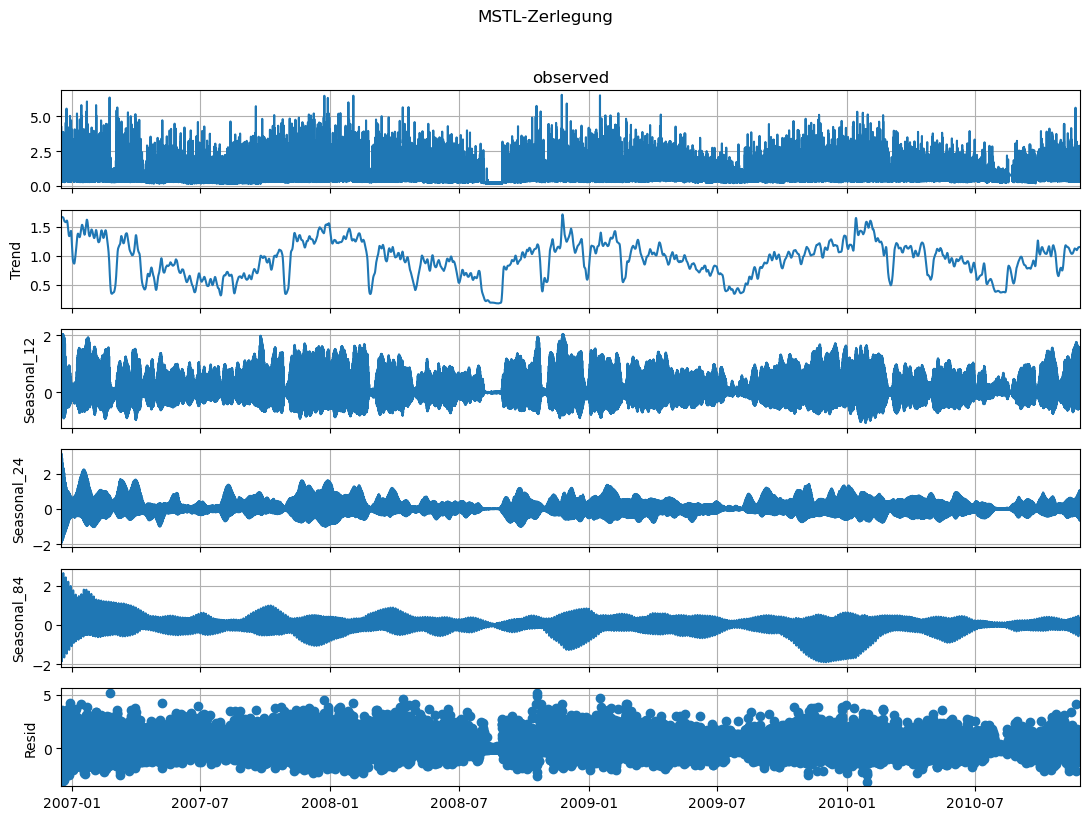

In [49]:
if MSTL is None:
    print("MSTL ist in der installierten statsmodels-Version nicht verfügbar. Bitte statsmodels aktualisieren.")
    mstl_result = None
else:
    min_required = 2 * max(MSTL_PERIODS)
    if len(decomp_series) < min_required:
        raise ValueError(
            f"Für MSTL sind mindestens zwei vollständige Zyklen der größten Periode sinnvoll. "
            f"Vorhanden: {len(decomp_series)}, benötigt: {min_required}."
        )

    mstl_result = MSTL(
        decomp_series,
        periods=MSTL_PERIODS,
        stl_kwargs={"robust": STL_ROBUST},
    ).fit()

    fig = mstl_result.plot()
    fig.set_size_inches(11, 8)
    fig.suptitle("MSTL-Zerlegung", y=1.02)
    fig.tight_layout()
    plt.show()

## Vergleich STL vs. MSTL

STL verwendet hier eine Hauptperiode. MSTL kann mehrere saisonale Komponenten berücksichtigen. Die gewählten Perioden sind Kandidaten aus Fachwissen und Welch-PSD.

Der Vergleich betrachtet die Größe des Residuums und die verbliebene Autokorrelation. Ein kleineres Residuum allein reicht nicht aus; wichtig ist auch, ob typische periodische Struktur reduziert wurde.


In [51]:
def residual_metrics(residual, relevant_lags=MSTL_PERIODS, max_lag=None):
    """Kompakte Kennwerte für Residuen berechnen."""
    clean = pd.Series(residual).dropna()

    if max_lag is None:
        max_lag = max(240, max(relevant_lags) + 24)

    nlags = min(max_lag, len(clean) - 2)
    acf_values = acf(clean, nlags=nlags, fft=True)
    metrics = {
        "resid_std": clean.std(),
        "resid_mad_mean": clean.sub(clean.mean()).abs().mean(),
        "max_abs_acf_1_to_max_lag": np.max(np.abs(acf_values[1:])) if nlags >= 1 else np.nan,
    }
    for lag in relevant_lags:
        metrics[f"acf_lag_{lag}"] = acf_values[lag] if lag <= nlags else np.nan
    return metrics

stl_resid = pd.Series(stl_result.resid, index=decomp_series.index, name="STL-Residuum")

if mstl_result is not None:
    mstl_resid = pd.Series(mstl_result.resid, index=decomp_series.index, name="MSTL-Residuum")
    comparison = pd.DataFrame(
        {
            "STL": residual_metrics(stl_resid),
            "MSTL": residual_metrics(mstl_resid),
        }
    )
    display(comparison)
else:
    mstl_resid = None
    print("Kein MSTL-Vergleich möglich, weil MSTL nicht verfügbar ist.")


,STL,MSTL
resid_std,0.656772,0.653868
resid_mad_mean,0.398148,0.413520
max_abs_acf_1_to_max_lag,0.511415,0.536789
acf_lag_12,-0.001931,0.008168
acf_lag_24,0.014216,0.016712
acf_lag_84,0.015345,-0.022428


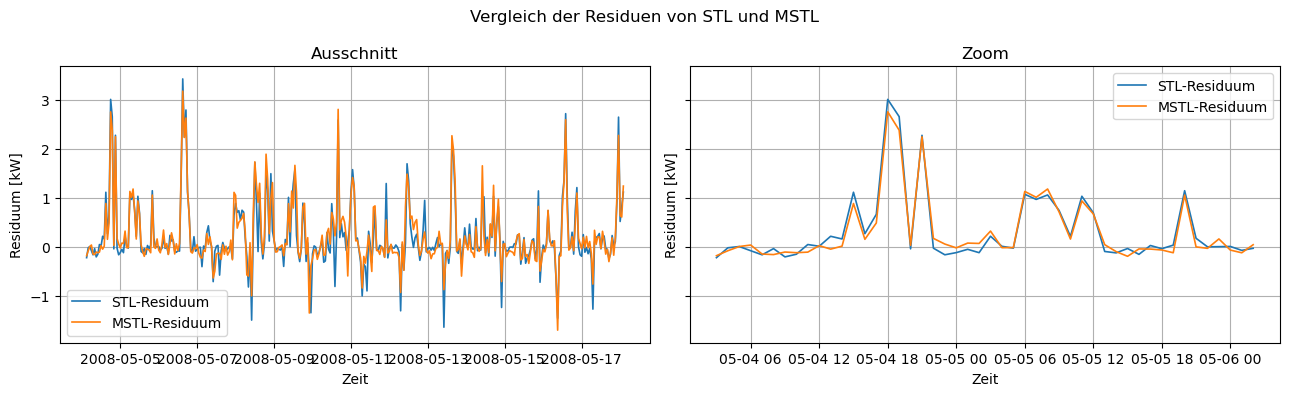

In [52]:
if mstl_resid is not None:
    plot_overview_and_zoom(
        {
            "STL-Residuum": stl_resid,
            "MSTL-Residuum": mstl_resid,
        },
        ylabel=f"Residuum [{VALUE_UNIT}]",
        title="Vergleich der Residuen von STL und MSTL",
    )

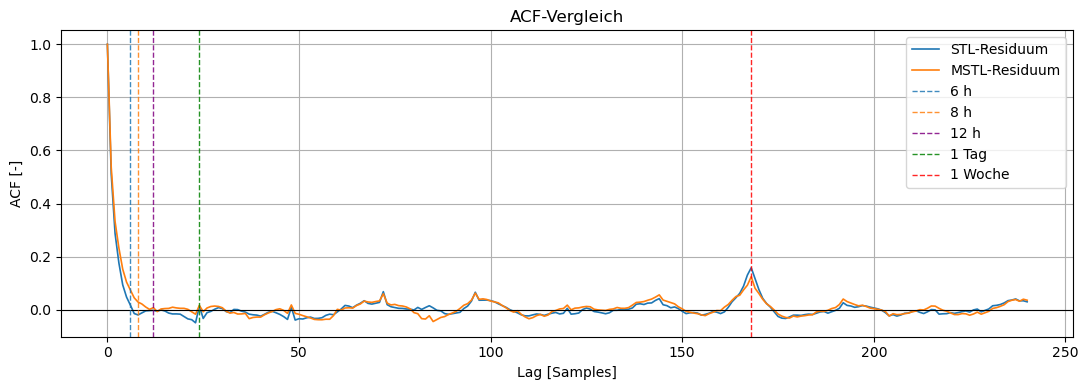

In [53]:
if mstl_resid is not None:
    plot_acf_comparison(stl_resid, mstl_resid, "STL-Residuum", "MSTL-Residuum", nlags=240)

## Interpretation

Ein gutes Residuum ist nicht nur klein. Es sollte möglichst wenig systematische Struktur enthalten.

Prüfen Sie:

- Ist im Zeitplot noch ein Muster sichtbar?
- Zeigt die ACF noch deutliche Ausschläge?
- Sind typische Perioden noch erkennbar?
- Entfernt MSTL mehrere saisonale Muster besser als STL?

Wenn nach STL noch ein Wochenmuster im Residuum erkennbar ist, spricht das für eine mehrperiodische Zerlegung mit MSTL. Wenn auch nach MSTL deutliche Struktur bleibt, kann das auf weitere Betriebszyklen, Trendbrüche, nichtstationäres Verhalten oder besondere Ereignisse hinweisen.

## Übungsaufgaben

1. Ändern Sie den betrachteten Zeitraum und prüfen Sie, ob die gleichen Muster sichtbar bleiben.
2. Wechseln Sie die Zielspalte, zum Beispiel auf `Global_intensity` oder `Voltage`, und interpretieren Sie die Unterschiede.
3. Vergleichen Sie lineare/rekursive Interpolation und kubische Spline-Interpolation an einer ausgewählten Lücke.
4. Ändern Sie die Cutoff-Periode des Tiefpassfilters und beurteilen Sie die Filterwirkung.
5. Vergleichen Sie Periodogramm und Welch-PSD für kurze und lange Datenfenster.
6. Ändern Sie die Resampling-Frequenz und beschreiben Sie den Informationsverlust.
7. Führen Sie STL mit einer begründeten Hauptperiode aus.
8. Führen Sie MSTL mit mehreren begründeten Perioden aus.
9. Vergleichen Sie die Residuen im Zeitplot, in der ACF und im Spektrum.
10. Formulieren Sie eine Empfehlung, welche Datenvariante für ein späteres Monitoring-Modell geeignet wäre.
